In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

old_set_bounds = mpl.patches.FancyBboxPatch.set_bounds # don't run this more than once!

In [2]:
import importlib
importlib.reload(plottery)

<module 'snp' from '/Users/brian/Documents/ucsd/bimodal_plotting/sketch-neo-plot/src/snp.py'>

### STUDY ONE AND TWO

In [3]:
participants = ('P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10', 'Mean')
expert       = (0,     1,   0,     1,   1,    0,    1,     0,    1,    0,     0   )


interaction_counts = { 'Code': [5,  6, 12, 1,  15, 1,  6, 13, 4, 17],
                       'GUI':  [15, 0, 4,  2,  4,  10, 0, 5, 15, 13],
                       'AI':   [5,  7, 4,  11, 4,  4,  9, 23, 6, 7]  }

interaction_percentages = { 'Code': [8.7,  24.1, 50.5, 0.7,  20.4, 3.3,  19.6,   17.3, 27.6, 41.6],
                            'GUI':  [30.1, 0.0,  18.0, 5.7,  11.3, 60.7,  0.0,   6.5,  40.0, 20.0],
                            'AI':   [61.17, 75.9, 31.5, 93.6, 68.3, 36.0, 80.4, 76.2, 32.4, 38.4]  }


participants2 = ('P4', 'P7', 'P9', 'P10', 'Mean')

interaction_counts2 = { 'Code': [7, 54, 101, 38],
                        'GUI':  [85, 35, 58, 27],
                        'AI':   [54, 44, 16, 30]  }

interaction_times2 = { 'Code': [19.6, 136.8, 961.2, 287],
                       'GUI':  [330.7, 223.3, 194, 118.4],
                       'AI':   [1879.3, 1352, 440.7, 1455.9]  }


interaction_percentages2 = {}
modes = list(interaction_times2.keys())

for mode in modes:
    interaction_percentages2[mode] = []
    for participant_i in range(len(participants2) - 1):
        t = interaction_times2[mode][participant_i]
        total_t = sum(interaction_times2[m][participant_i] for m in modes)
        interaction_percentages2[mode].append(round(t / total_t * 100, 1))

for key in interaction_counts:
    vals = interaction_counts[key]
    interaction_counts[key].append(round(sum(vals) / len(vals), 1))
    vals2 = interaction_counts2[key]
    interaction_counts2[key].append(round(sum(vals2) / len(vals2), 1))

for key in interaction_percentages:
    vals = interaction_percentages[key]
    interaction_percentages[key].append(round(sum(vals) / len(vals), 1))
    vals2 = interaction_percentages2[key]
    interaction_percentages2[key].append(round(sum(vals2) / len(vals2), 1))
    

print(interaction_percentages2)

{'Code': [0.9, 8.0, 60.2, 15.4, 21.1], 'GUI': [14.8, 13.0, 12.2, 6.4, 11.6], 'AI': [84.3, 79.0, 27.6, 78.2, 67.3]}


In [4]:
# distance to infinitely long line passing through pt1 and pt2
def distance_to_line(pt, pt1, pt2):
    
    # translate so pt1 is 0,0
    x2 = pt2[0] - pt1[0]
    y2 = pt2[1] - pt1[1]
    x  = pt[0]  - pt1[0]
    y  = pt[1]  - pt1[1]

    # find unit vector
    segment_length = (x2**2 + y2**2)**0.5

    ux2 = x2 / segment_length
    uy2 = y2 / segment_length

    # project point onto line
    distance_from_origin_on_line = x*ux2 + y*uy2

    x_proj = ux2 * distance_from_origin_on_line
    y_proj = uy2 * distance_from_origin_on_line

    # distance to projection
    return ((x-x_proj)**2 + (y-y_proj)**2)**0.5


def goodness(code_amt, gui_amt, ai_amt, no_code_distance, no_gui_distance, no_ai_distance):
    amts                 = np.array([code_amt, gui_amt, ai_amt])
    distances_rev        = np.array([no_code_distance, no_gui_distance, no_ai_distance])
    amts_ratios          = amts / sum(amts)
    distances_rev_ratios = distances_rev / sum(distances_rev)
#     print(amts_ratios)
#     print(distances_rev_ratios)
    return sum(abs(distances_rev_ratios - amts_ratios))

In [5]:
tri_xs = [-0.5, 0,        0.5, -0.5]
tri_ys = [0,    3**0.5/2, 0  , 0]

code_pt = (tri_xs[0], tri_ys[0])
gui_pt  = (tri_xs[1], tri_ys[1])
ai_pt   = (tri_xs[2], tri_ys[2])

In [6]:
def goodness2(pt, data, participant_i):
    no_gui_distance  = distance_to_line(pt, code_pt, ai_pt)
    no_ai_distance   = distance_to_line(pt, code_pt, gui_pt)
    no_code_distance = distance_to_line(pt, gui_pt,  ai_pt)

    code_amt = data['Code'][participant_i]
    gui_amt  = data['GUI'][participant_i]
    ai_amt   = data['AI'][participant_i]

    return goodness(code_amt, gui_amt, ai_amt, no_code_distance, no_gui_distance, no_ai_distance)


In [7]:
import random

def find_best(data, participant_i):
    pt = 0, 0.4
    dist = 10000

    while dist > 0.0001:
        dx = (random.random() - 0.5) * 0.01
        dy = (random.random() - 0.5) * 0.01
        
        new_pt = pt[0] + dx, pt[1] + dy
        
        if goodness2(new_pt, data, participant_i) < dist:
            pt = new_pt
            dist = goodness2(pt, data, participant_i)
#             print(dist)

#     print(participant_i, dist, pt)
    return pt

In [8]:
interaction_time_xs = []
interaction_time_ys = []

for participant_i in range(len(participants)):
    x, y = find_best(interaction_percentages, participant_i)
    interaction_time_xs.append(x)
    interaction_time_ys.append(y)

print(interaction_time_xs)
print(interaction_time_ys)

interaction_counts_xs = []
interaction_counts_ys = []

for participant_i in range(len(participants)):
    x, y = find_best(interaction_counts, participant_i)
    interaction_counts_xs.append(x)
    interaction_counts_ys.append(y)

print(interaction_counts_xs)
print(interaction_counts_ys)

[0.262398914700179, 0.25900650534567216, -0.09500910915502979, 0.4645096014588529, 0.2394738681123851, 0.16348177725321872, 0.303962946560331, 0.29448429587565295, 0.024000949320367823, -0.01600331070425289, 0.1900144803054223]
[0.2607407755737612, 2.3444212357114506e-05, 0.155913594839119, 0.049401376195346486, 0.09788458751963632, 0.5257076130647071, 4.989747905931862e-06, 0.05632149580159554, 0.34642602383300636, 0.17318573054228312, 0.1662465619754268]
[-3.848335201722312e-05, 0.03842775065434174, -0.2000343437169177, 0.3571442752330354, -0.2391307366496588, 0.10001750710346907, 0.10002419667263106, 0.1219241029580563, 0.04001529097881753, -0.13517723048072006, 4.6227471315941885e-05]
[0.5196193375704823, 6.644264616389984e-07, 0.1731896982584806, 0.12369374592545129, 0.15060645186364902, 0.5773442857842166, -3.221733490720453e-05, 0.10559057083740642, 0.5196437108971451, 0.3042778456043397, 0.25828635542064066]


In [9]:
interaction_time_xs2 = []
interaction_time_ys2 = []

for participant_i in range(len(participants2)):
    x, y = find_best(interaction_percentages2, participant_i)
    interaction_time_xs2.append(x)
    interaction_time_ys2.append(y)

print(interaction_time_xs2)
print(interaction_time_ys2)

interaction_counts_xs2 = []
interaction_counts_ys2 = []

for participant_i in range(len(participants2)):
    x, y = find_best(interaction_counts2, participant_i)
    interaction_counts_xs2.append(x)
    interaction_counts_ys2.append(y)

print(interaction_counts_xs2)
print(interaction_counts_ys2)

[0.4169551479475498, 0.35497117104308284, -0.16297828832424818, 0.3139882348906223, 0.23095956306341708]
[0.12817107560048105, 0.1126123905951602, 0.10565768683728043, 0.05540737280738291, 0.10045504330149246]
[0.16094858650379393, -0.037599040801728434, -0.24286222203444902, -0.042080511091001194, -0.05099736854356665]
[0.504202760461629, 0.22788755198111044, 0.28701719096171696, 0.24617386426047946, 0.3231644543460784]


In [10]:
import IPython
import time

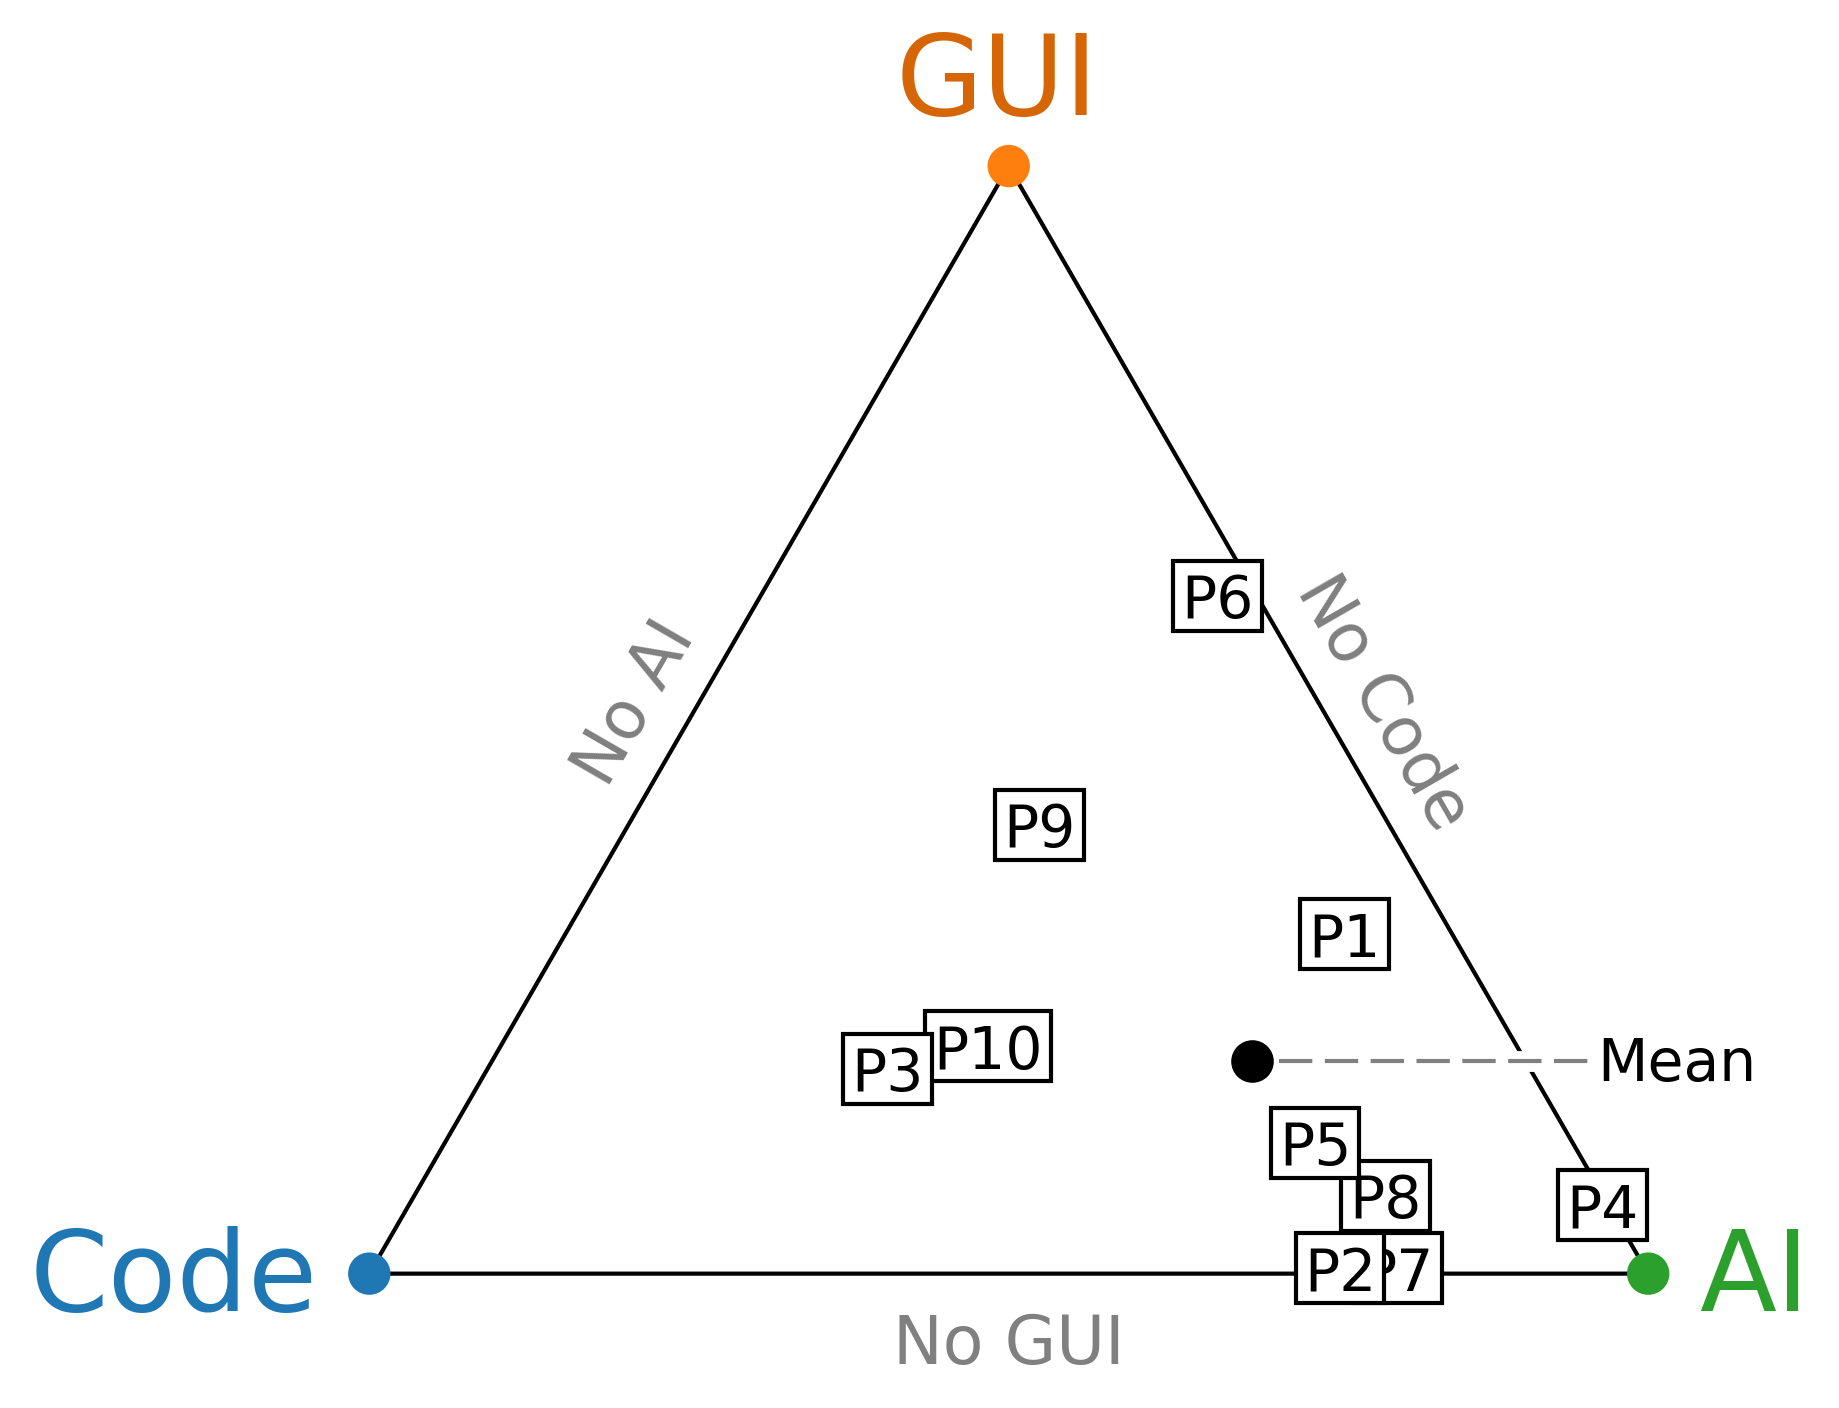

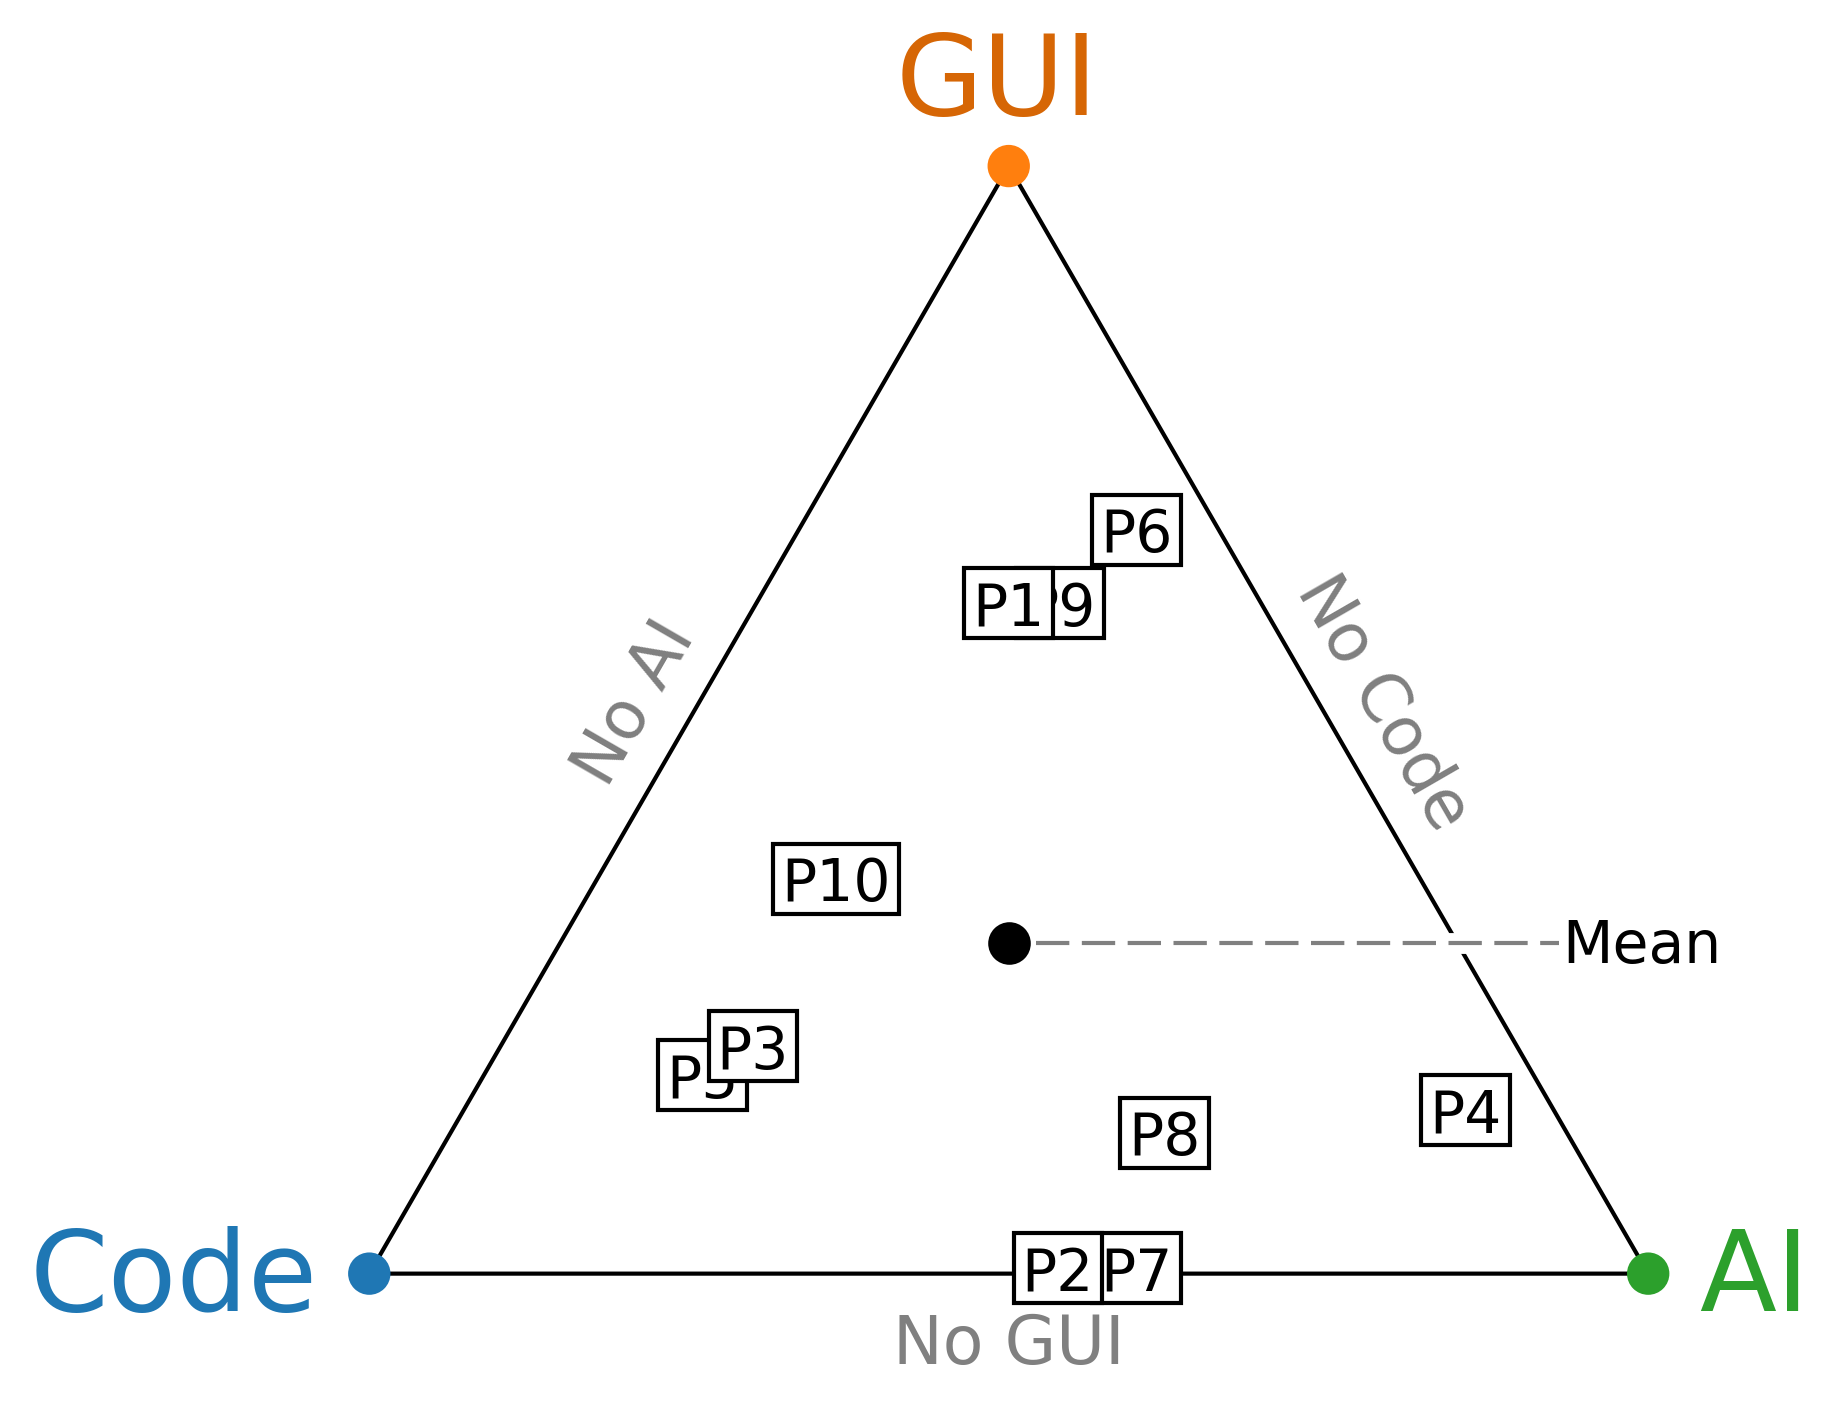

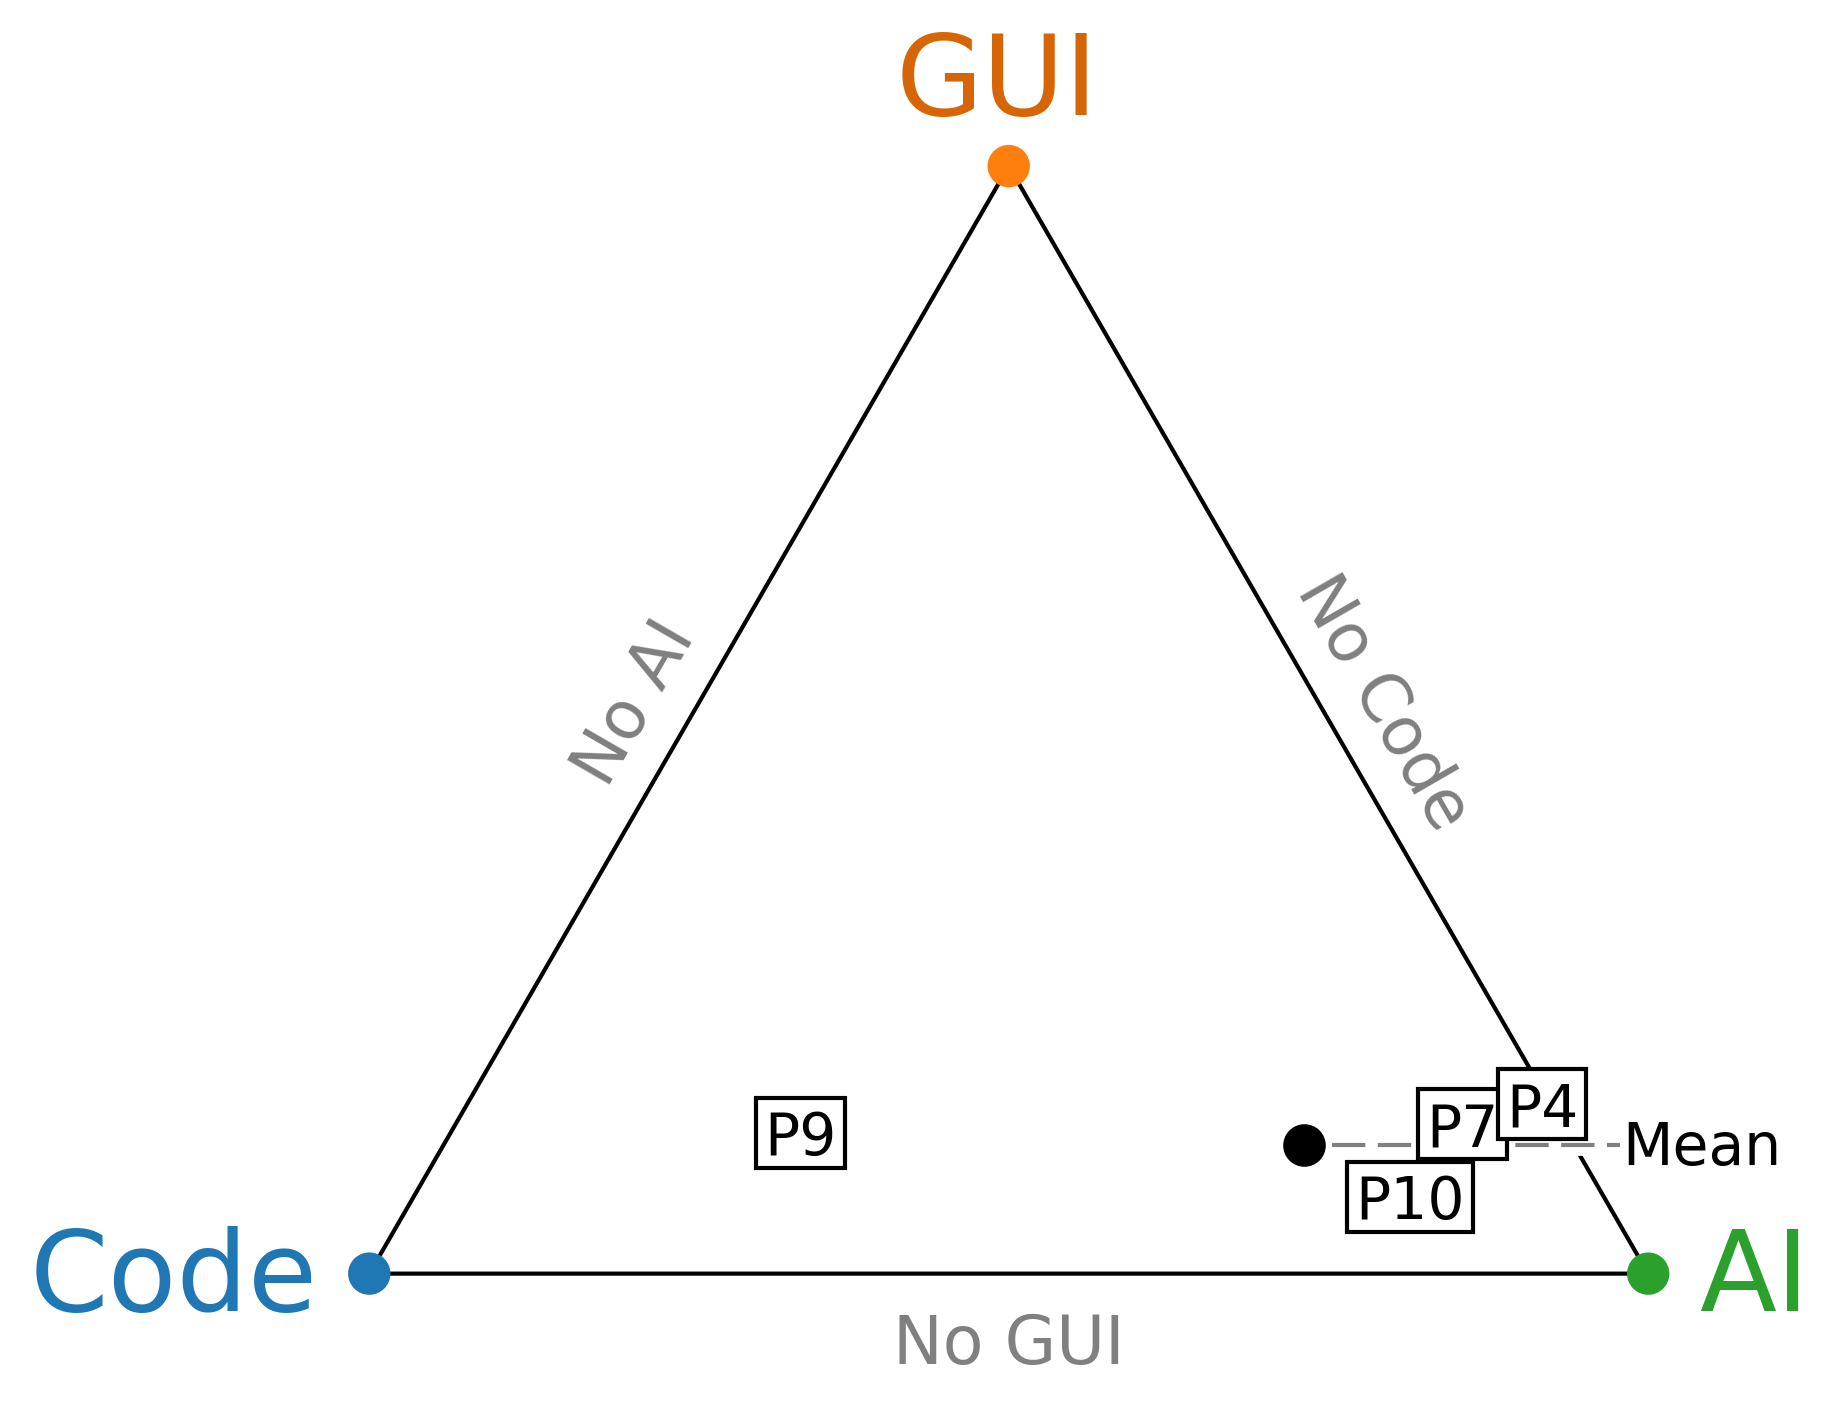

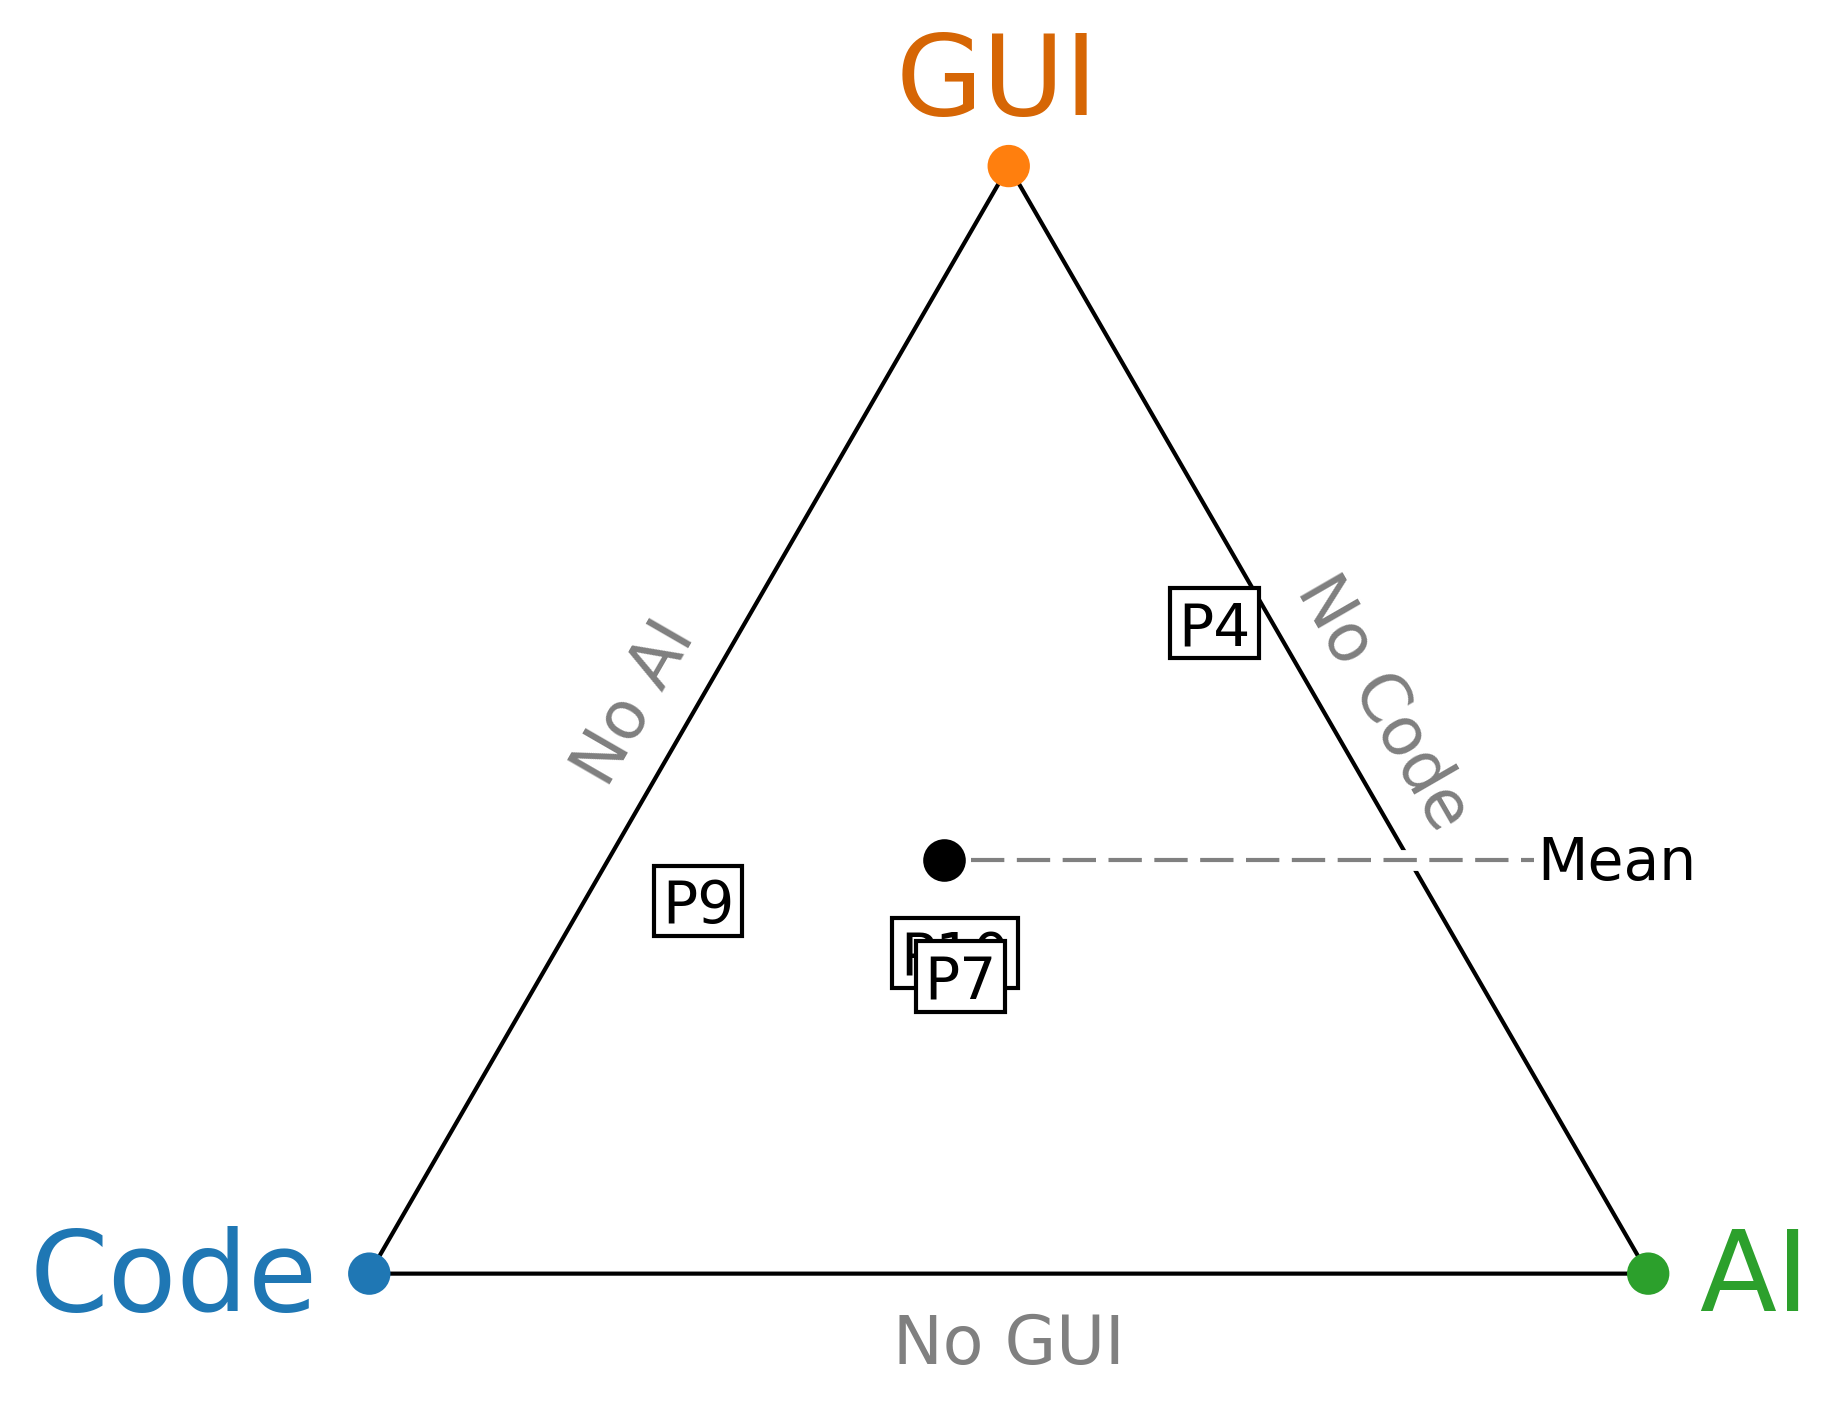

In [79]:
from matplotlib import patheffects
import matplotlib.patches as patches

# Hack to control bbox sizing
def new_set_bounds(self, x, y, w, h):
    return old_set_bounds(self, x, y, w, h*1.2)
mpl.patches.FancyBboxPatch.set_bounds = new_set_bounds


def tri_plot(title, participants, xs, ys):
    fig = plt.figure(layout='tight', facecolor=(1,1,1,0), dpi=300)
    ax = fig.add_subplot(1, 1, 1)

    # extracted this manually, of course
    border_color = 'black'
    edge_text_color = (0.5, 0.5, 0.5)

    # didn't have to look up the joinstyle docs to get the sharp corners, I would have guessed "sharp"
    ax.plot(tri_xs, tri_ys, color=border_color, solid_joinstyle='miter', linewidth=1)

    # Used AI for this line
    ax.set_aspect('equal', adjustable='box')

    # Learned this line from using AI for the overview example
    # entered manually here after AI gave too many lines of code for the same thing
    ax.axis('off')

    # was nice to be able to try out properties to e.g. toggle on rotation_mode
    # [dec 9, lisa] the three lines below were in comments before, so AI unexpectedly ate them. BAD
    text9 = ax.text(0.27, 3**0.5/4, 'No Code', color=edge_text_color, horizontalalignment='center', rotation=-60, verticalalignment='bottom', rotation_mode='anchor', fontsize=16)
    text11 = ax.text(-0.27, 3**0.5/4, 'No AI', color=edge_text_color, horizontalalignment='center', rotation=60, verticalalignment='bottom', rotation_mode='anchor', fontsize=16)
    # [dec 9, lisa] used drag and drop to reposition it to avoid text overlapping :)
    text12 = ax.text(0, -0.03, 'No GUI', color=edge_text_color, horizontalalignment='center', verticalalignment='top', fontsize=16)

    for i, name in reversed(list(enumerate(participants))):
        # [dec 9, lisa] AI wrote this part to separate letters and numbers from every name, very helpful
        # split text into two parts: alphabets and numbers
        alpha_part = ''.join(filter(str.isalpha, name))
        numeric_part = ''.join(filter(str.isdigit, name))

        # [dec 9, lisa] I wrote this conditional in code to handle special formatting for "Mean"
                        # however, plottery doesn't show layers within a conditional at all, so I can't use the GUI to tweak it
        if (alpha_part == 'Mean'):
            continue
            # text for letters with partial opacity
#             text_alpha = ax.text(xs[i], ys[i], alpha_part, horizontalalignment='center', verticalalignment='center', fontweight='bold', fontsize=14)
#             text_alpha.set_path_effects([patheffects.withStroke(linewidth=1, foreground='white')])

        # [dec 9, lisa] AI generated the code for bbox to adjust padding, which was very helpful
                        # I then used plottery to tweak the coloring and linewidth etc.
        # text for numbers with full opacity and smaller padding
        text_numeric = ax.text(xs[i], ys[i], f'{alpha_part}{numeric_part}', horizontalalignment='center', verticalalignment='center', fontweight='normal', fontsize=14, bbox=dict(pad=2, edgecolor=(0, 0, 0, 1), facecolor='white', mutation_aspect=0.1))        

        # [sept 2 2025, brian] added this line by hand to get more control over the bbox positioning; bbox arg in above doesnt let us fine-tune the postion
#         text_numeric._bbox_patch = mpl.patches.FancyBboxPatch((0, 0), 1, 1, boxstyle='square,pad=0.2', edgecolor=(0, 0, 0, 1), facecolor='white')

    # Would be really nice to link properties, e.g. fontsize here (Sketch-n-Sketch Make Equal)
    text4 = ax.text(tri_xs[1] + -0.009, tri_ys[1] + 0.04, 'GUI', fontsize=27, horizontalalignment='center', color=(0.84, 0.40, 0.02))
    text5 = ax.text(tri_xs[0] + -0.04, tri_ys[0] + -0.005, 'Code', fontsize=27, horizontalalignment='right', color='C0', verticalalignment='center')

    # Poor man's alignment: used slider for x after duplicating the above line
    text6 = ax.text(tri_xs[2] + 0.04, tri_ys[2] + -0.005, 'AI', fontsize=27, horizontalalignment='left', color='C2', verticalalignment='center')

    # text8 = ax.set_title(title, y=-0.29, fontsize=25, fontweight='demi')

    # [sept 2 2025, brian] Added/editted with GUI
    corner_dots = ax.scatter(tri_xs, tri_ys, facecolors=['C0', 'C1', 'C2', 'none'], zorder=2, s=84)

    
    
    # [sept 2 2025, brian] Added these with GUI, a little bit of code editing
    mean_dot = ax.scatter(xs[-1], ys[-1], s=85, c='black', zorder=3)
    white_bk_line = ax.plot([xs[-1], ys[-1]*-0.3 + 0.51], [ys[-1], ys[-1]], color=(1.00, 1.00, 1.00), linewidth=5)
    mean_line = ax.plot([xs[-1] + 0.0215, ys[-1]*-0.3 + 0.508], [ys[-1], ys[-1]], color=edge_text_color, linewidth=1, dashes=(8,3))
    mean_label = ax.text(ys[-1]*-0.3 + 0.51, ys[-1] + -0.0025, 'Mean', fontsize=14, verticalalignment='center')

    (plt).show()

tri_plot('Interaction Time', participants, interaction_time_xs, interaction_time_ys)
tri_plot('Interaction Counts', participants, interaction_counts_xs, interaction_counts_ys)

tri_plot('Interaction Time', participants2, interaction_time_xs2, interaction_time_ys2)
tri_plot('Interaction Counts', participants2, interaction_counts_xs2, interaction_counts_ys2)

In [ ]:
# keep this version around for historical purposes

fig = plt.figure(layout='tight', dpi=300)
ax = fig.add_subplot(1, 1, 1)

ax.plot(tri_xs, tri_ys)

# had to ask the AI for this line
ax.set_aspect('equal', adjustable='box')

# paths = ax.scatter(0.205, 0.405)
paths = ax.scatter(0.2, 0.4)

participant_i = 0

pt = paths.get_offsets()[participant_i]

no_gui_distance  = distance_to_line(pt, code_pt, ai_pt)
no_ai_distance   = distance_to_line(pt, code_pt, gui_pt)
no_code_distance = distance_to_line(pt, gui_pt,  ai_pt)

text = ax.text(-0.49, 0.82,  f'Point: {pt}')
text = ax.text(-0.09, -0.03, f'{no_gui_distance:.3f}')
text = ax.text(-0.38, 0.49, f'{no_ai_distance:.3f}')
text = ax.text(0.28, 0.5,    f'{no_code_distance:.3f}')

code_amt = interaction_percentages['Code'][participant_i]
gui_amt  = interaction_percentages['GUI'][participant_i]
ai_amt   = interaction_percentages['AI'][participant_i]

dist = goodness(code_amt, gui_amt, ai_amt, no_code_distance, no_gui_distance, no_ai_distance)

text2 = ax.text(-0.49, 0.745, f'Loss: {dist:.3f}', fontweight='bold')

plt.show()

### STUDY TWO (old, above now plots both)

In [ ]:
participants = ('P4', 'P7', 'P9', 'P10', 'Mean')

interaction_counts = { 'Code': [7, 54, 101, 38],
                       'GUI':  [85, 35, 58, 27],
                       'AI':   [54, 44, 16, 30]  }

interaction_time = { 'Code': [19.6, 136.8, 961.2, 287],
                            'GUI':  [330.7, 223.3, 194, 118.4],
                            'AI':   [1879.3, 1352, 440.7, 1455.9]  }

In [ ]:
time_by_participants = {}

for i in range(len(participants[:-1])):
    participant = participants[i]
    time = []
    for key in interaction_time:
        time.append(interaction_time[key][i])
    time_by_participants[participant] = time
    
time_by_participants

In [ ]:
interaction_percentages = {'Code': [], 'GUI': [], 'AI': []}
for p in time_by_participants:
    total_time = sum(time_by_participants[p])
    for i in range(len(time_by_participants[p])):
        time = time_by_participants[p][i]
        # bad code but we don't care
        if i == 0:
            interaction_percentages['Code'].append(round(time / total_time * 100, 2))
        if i == 1:
            interaction_percentages['GUI'].append(round(time / total_time * 100, 2))
        if i == 2:
            interaction_percentages['AI'].append(round(time / total_time * 100, 2))
            
interaction_percentages

In [ ]:
for key in interaction_counts:
    vals = interaction_counts[key]
    interaction_counts[key].append(round(sum(vals) / len(vals), 1))


for key in interaction_percentages:
    vals = interaction_percentages[key]
    interaction_percentages[key].append(round(sum(vals) / len(vals), 1))

In [ ]:
# distance to infinitely long line passing through pt1 and pt2
def distance_to_line(pt, pt1, pt2):
    
    # translate so pt1 is 0,0
    x2 = pt2[0] - pt1[0]
    y2 = pt2[1] - pt1[1]
    x  = pt[0]  - pt1[0]
    y  = pt[1]  - pt1[1]

    # find unit vector
    segment_length = (x2**2 + y2**2)**0.5

    ux2 = x2 / segment_length
    uy2 = y2 / segment_length

    # project point onto line
    distance_from_origin_on_line = x*ux2 + y*uy2

    x_proj = ux2 * distance_from_origin_on_line
    y_proj = uy2 * distance_from_origin_on_line

    # distance to projection
    return ((x-x_proj)**2 + (y-y_proj)**2)**0.5


def goodness(code_amt, gui_amt, ai_amt, no_code_distance, no_gui_distance, no_ai_distance):
    amts                 = np.array([code_amt, gui_amt, ai_amt])
    distances_rev        = np.array([no_code_distance, no_gui_distance, no_ai_distance])
    amts_ratios          = amts / sum(amts)
    distances_rev_ratios = distances_rev / sum(distances_rev)
#     print(amts_ratios)
#     print(distances_rev_ratios)
    return sum(abs(distances_rev_ratios - amts_ratios))

In [ ]:
tri_xs = [-0.5, 0,        0.5, -0.5]
tri_ys = [0,    3**0.5/2, 0  , 0]

code_pt = (tri_xs[0], tri_ys[0])
gui_pt  = (tri_xs[1], tri_ys[1])
ai_pt   = (tri_xs[2], tri_ys[2])

In [ ]:
def goodness2(pt, data, participant_i):
    no_gui_distance  = distance_to_line(pt, code_pt, ai_pt)
    no_ai_distance   = distance_to_line(pt, code_pt, gui_pt)
    no_code_distance = distance_to_line(pt, gui_pt,  ai_pt)

    code_amt = data['Code'][participant_i]
    gui_amt  = data['GUI'][participant_i]
    ai_amt   = data['AI'][participant_i]

    return goodness(code_amt, gui_amt, ai_amt, no_code_distance, no_gui_distance, no_ai_distance)


In [ ]:
import random

def find_best(data, participant_i):
    pt = 0, 0.4
    dist = 10000

    while dist > 0.0001:
        dx = (random.random() - 0.5) * 0.01
        dy = (random.random() - 0.5) * 0.01
        
        new_pt = pt[0] + dx, pt[1] + dy
        
        if goodness2(new_pt, data, participant_i) < dist:
            pt = new_pt
            dist = goodness2(pt, data, participant_i)
#             print(dist)

#     print(participant_i, dist, pt)
    return pt

In [ ]:
interaction_time_xs = []
interaction_time_ys = []

for participant_i in range(len(participants)):
    x, y = find_best(interaction_percentages, participant_i)
    interaction_time_xs.append(x)
    interaction_time_ys.append(y)

print(interaction_time_xs)
print(interaction_time_ys)

interaction_counts_xs = []
interaction_counts_ys = []

for participant_i in range(len(participants)):
    x, y = find_best(interaction_counts, participant_i)
    interaction_counts_xs.append(x)
    interaction_counts_ys.append(y)

print(interaction_counts_xs)
print(interaction_counts_ys)

In [ ]:
import IPython
import time

In [ ]:
from matplotlib import patheffects
import matplotlib.patches as patches

def tri_plot(title, xs, ys):
    fig = plt.figure(layout='tight', dpi=300, facecolor=(1,1,1,0))
    ax = fig.add_subplot(1, 1, 1)

    # extracted this manually, of course
    border_color = (0.42, 0.42, 0.42)

    # didn't have to look up the joinstyle docs to get the sharp corners, I would have guessed "sharp"
    ax.plot(tri_xs, tri_ys, color=border_color, solid_joinstyle='miter')

    # Used AI for this line
    ax.set_aspect('equal', adjustable='box')

    # Learned this line from using AI for the overview example
    # entered manually here after AI gave too many lines of code for the same thing
    ax.axis('off')
    
    # was nice to be able to try out properties to e.g. toggle on rotation_mode
    # [dec 9, lisa] the three lines below were in comments before, so AI unexpectedly ate them. BAD
    text9 = ax.text(0.246, 3**0.5/4, 'No Code', color=border_color, horizontalalignment='center', rotation=-60, verticalalignment='bottom', rotation_mode='anchor', fontsize='large')
    text11 = ax.text(-0.246, 3**0.5/4, 'No AI', color=border_color, horizontalalignment='center', rotation=60, verticalalignment='bottom', rotation_mode='anchor', fontsize='large')
    # [dec 9, lisa] used drag and drop to reposition it to avoid text overlapping :)
    text12 = ax.text(0.03, -0.05, 'No GUI', color=border_color, horizontalalignment='center', verticalalignment='top', fontsize='large')

    for i, name in enumerate(participants):
        
        # [dec 9, lisa] AI wrote this part to separate letters and numbers from every name, very helpful
        # split text into two parts: alphabets and numbers
        alpha_part = ''.join(filter(str.isalpha, name))
        numeric_part = ''.join(filter(str.isdigit, name))
        
        # [dec 9, lisa] I wrote this conditional in code to handle special formatting for "Mean"
                        # however, plottery doesn't show layers within a conditional at all, so I can't use the GUI to tweak it
        if (alpha_part == 'Mean'):
            # text for letters with partial opacity
            text_alpha = ax.text(xs[i], ys[i], alpha_part, horizontalalignment='center', verticalalignment='center', fontweight='bold', fontsize=14)
            text_alpha.set_path_effects([patheffects.withStroke(linewidth=1, foreground='white')])
        
        # [dec 9, lisa] AI generated the code for bbox to adjust padding, which was very helpful
                        # I then used plottery to tweak the coloring and linewidth etc.
        # text for numbers with full opacity and smaller padding
        text_numeric = ax.text(xs[i], ys[i], numeric_part, horizontalalignment='center', verticalalignment='center', fontweight='bold', fontsize=14, alpha=1, bbox=dict(pad=1, edgecolor=(0, 0, 0, 1), facecolor='white'))

    # Would be really nice to link properties, e.g. fontsize here (Sketch-n-Sketch Make Equal)
    text4 = ax.text(-0.009, 0.9, 'GUI', fontsize=30, horizontalalignment='center', color='C1')
    text5 = ax.text(-0.49, -0.08, 'Code', fontsize=30, horizontalalignment='right', color='C0')

    # Poor man's alignment: used slider for x after duplicating the above line
    text6 = ax.text(0.52, -0.08, 'AI', fontsize=30, horizontalalignment='left', color='C2')

    text8 = ax.set_title(title, y=-0.29, fontsize=25, fontweight='demi')

    plt.show()

tri_plot('Interaction Time', interaction_time_xs, interaction_time_ys)
out = tri_plot('Interaction Counts', interaction_counts_xs, interaction_counts_ys)

## STUDY ONE MODALITY USE BREAKDOWN

In [ ]:
participants = ('P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10', 'Mean')
expert       = (0,     1,   0,     1,   1,    0,    1,     0,    1,    0,     0   )


add_counts =         { 'Code': [0.00001, 0.00001, 7, 0.00001, 5, 0.00001, 0.00001, 0.00001, 0.00001, 6],
                       'GUI':  [1, 0.00001, 1, 1, 3, 1, 0.00001, 3, 5, 1],
                       'AI':   [2, 4, 2, 4, 1, 3, 1, 1, 4, 6]  }

remove_counts =      { 'Code': [5, 0.00001, 0.00001, 1, 6, 1, 0.00001, 0.00001, 0.00001, 1],
                       'GUI':  [3, 0.00001, 0.00001, 0.00001, 0.00001, 1, 0.00001, 0.00001, 0.00001, 0.00001],
                       'AI':   [1, 0.00001, 1, 2, 1, 0.00001, 1, 0.00001, 0.00001, 0.00001]  }

restyle_counts =     { 'Code': [0.00001, 6, 4, 0.00001, 3, 0.00001, 6, 13, 1, 10],
                       'GUI':  [10, 0.00001, 3, 1, 0.00001, 5, 0.00001, 2, 9, 12],
                       'AI':   [2, 3, 1, 5, 2, 1, 7, 21, 2, 1]  }



for key in add_counts:
    vals = add_counts[key]
    add_counts[key].append(round(sum(vals) / len(vals), 1))
    
for key in remove_counts:
    vals = remove_counts[key]
    remove_counts[key].append(round(sum(vals) / len(vals), 1))
    
for key in restyle_counts:
    vals = restyle_counts[key]
    restyle_counts[key].append(round(sum(vals) / len(vals), 1))


In [ ]:
# distance to infinitely long line passing through pt1 and pt2
def distance_to_line(pt, pt1, pt2):
    
    # translate so pt1 is 0,0
    x2 = pt2[0] - pt1[0]
    y2 = pt2[1] - pt1[1]
    x  = pt[0]  - pt1[0]
    y  = pt[1]  - pt1[1]

    # find unit vector
    segment_length = (x2**2 + y2**2)**0.5

    ux2 = x2 / segment_length
    uy2 = y2 / segment_length

    # project point onto line
    distance_from_origin_on_line = x*ux2 + y*uy2

    x_proj = ux2 * distance_from_origin_on_line
    y_proj = uy2 * distance_from_origin_on_line

    # distance to projection
    return ((x-x_proj)**2 + (y-y_proj)**2)**0.5


def goodness(code_amt, gui_amt, ai_amt, no_code_distance, no_gui_distance, no_ai_distance):
    amts                 = np.array([code_amt, gui_amt, ai_amt])
    distances_rev        = np.array([no_code_distance, no_gui_distance, no_ai_distance])
    amts_ratios          = amts / sum(amts)
    distances_rev_ratios = distances_rev / sum(distances_rev)
#     print(amts_ratios)
#     print(distances_rev_ratios)
    return sum(abs(distances_rev_ratios - amts_ratios))

In [ ]:
tri_xs = [-0.5, 0,        0.5, -0.5]
tri_ys = [0,    3**0.5/2, 0  , 0]

code_pt = (tri_xs[0], tri_ys[0])
gui_pt  = (tri_xs[1], tri_ys[1])
ai_pt   = (tri_xs[2], tri_ys[2])

In [ ]:
def goodness2(pt, data, participant_i):
    no_gui_distance  = distance_to_line(pt, code_pt, ai_pt)
    no_ai_distance   = distance_to_line(pt, code_pt, gui_pt)
    no_code_distance = distance_to_line(pt, gui_pt,  ai_pt)

    code_amt = data['Code'][participant_i]
    gui_amt  = data['GUI'][participant_i]
    ai_amt   = data['AI'][participant_i]

    return goodness(code_amt, gui_amt, ai_amt, no_code_distance, no_gui_distance, no_ai_distance)


In [ ]:
import random

def find_best(data, participant_i):
    pt = 0, 0.4
    dist = 10000

    while dist > 0.0001:
        dx = (random.random() - 0.5) * 0.01
        dy = (random.random() - 0.5) * 0.01
        
        new_pt = pt[0] + dx, pt[1] + dy
        
        if goodness2(new_pt, data, participant_i) < dist:
            pt = new_pt
            dist = goodness2(pt, data, participant_i)
#             print(dist)

#     print(participant_i, dist, pt)
    return pt

In [ ]:
add_xs = []
add_ys = []

for participant_i in range(len(participants)):
    x, y = find_best(add_counts, participant_i)
    add_xs.append(x)
    add_ys.append(y)

print(add_xs)
print(add_ys)


remove_xs = []
remove_ys = []

for participant_i in range(len(participants)):
    x, y = find_best(remove_counts, participant_i)
    remove_xs.append(x)
    remove_ys.append(y)

print(remove_xs)
print(remove_ys)


restyle_xs = []
restyle_ys = []

for participant_i in range(len(participants)):
    x, y = find_best(restyle_counts, participant_i)
    restyle_xs.append(x)
    restyle_ys.append(y)

print(restyle_xs)
print(restyle_ys)


In [ ]:
import IPython
import time

In [ ]:
from matplotlib import patheffects
import matplotlib.patches as patches

def tri_plot(title, xs, ys):
    fig = plt.figure(layout='tight', dpi=300, facecolor=(1,1,1,0))
    ax = fig.add_subplot(1, 1, 1)

    # extracted this manually, of course
    border_color = (0.42, 0.42, 0.42)

    # didn't have to look up the joinstyle docs to get the sharp corners, I would have guessed "sharp"
    ax.plot(tri_xs, tri_ys, color=border_color, solid_joinstyle='miter')

    # Used AI for this line
    ax.set_aspect('equal', adjustable='box')

    # Learned this line from using AI for the overview example
    # entered manually here after AI gave too many lines of code for the same thing
    ax.axis('off')
    
    # was nice to be able to try out properties to e.g. toggle on rotation_mode
#     # [dec 9, lisa] the three lines below were in comments before, so AI unexpectedly ate them. BAD
#     text9 = ax.text(0.246, 3**0.5/4, 'No Code', color=border_color, horizontalalignment='center', rotation=-60, verticalalignment='bottom', rotation_mode='anchor', fontsize='large')
#     text11 = ax.text(-0.246, 3**0.5/4, 'No AI', color=border_color, horizontalalignment='center', rotation=60, verticalalignment='bottom', rotation_mode='anchor', fontsize='large')
#     # [dec 9, lisa] used drag and drop to reposition it to avoid text overlapping :)
#     text12 = ax.text(0.03, -0.05, 'No GUI', color=border_color, horizontalalignment='center', verticalalignment='top', fontsize='large')

    for i, name in enumerate(participants):
        
        # [dec 9, lisa] AI wrote this part to separate letters and numbers from every name, very helpful
        # split text into two parts: alphabets and numbers
        alpha_part = ''.join(filter(str.isalpha, name))
        numeric_part = ''.join(filter(str.isdigit, name))
        
        # [dec 9, lisa] I wrote this conditional in code to handle special formatting for "Mean"
                        # however, plottery doesn't show layers within a conditional at all, so I can't use the GUI to tweak it
        if (alpha_part == 'Mean'):
            # text for letters with partial opacity
            text_alpha = ax.text(xs[i], ys[i], alpha_part, horizontalalignment='center', verticalalignment='center', fontweight='bold', fontsize=14)
            text_alpha.set_path_effects([patheffects.withStroke(linewidth=1, foreground='white')])
        
        # [dec 9, lisa] AI generated the code for bbox to adjust padding, which was very helpful
                        # I then used plottery to tweak the coloring and linewidth etc.
        # text for numbers with full opacity and smaller padding
        text_numeric = ax.text(xs[i], ys[i], numeric_part, horizontalalignment='center', verticalalignment='center', fontweight='bold', fontsize=14, alpha=1, bbox=dict(pad=1, edgecolor=(0, 0, 0, 1), facecolor='white'))

    # Would be really nice to link properties, e.g. fontsize here (Sketch-n-Sketch Make Equal)
    text4 = ax.text(-0.009, 0.9, 'GUI', fontsize=30, horizontalalignment='center', color='C1')
    text5 = ax.text(-0.49, -0.08, 'Code', fontsize=30, horizontalalignment='right', color='C0')

    # Poor man's alignment: used slider for x after duplicating the above line
    text6 = ax.text(0.52, -0.08, 'AI', fontsize=30, horizontalalignment='left', color='C2')

    text8 = ax.set_title(title, y=-0.29, fontsize=25, fontweight='demi')

    plt.show()

tri_plot('Add Visual Counts', add_xs, add_ys)
tri_plot('Remove Visual Counts', remove_xs, remove_ys)
out = tri_plot('Restyle Visual Counts', restyle_xs, restyle_ys)
